# 017 — Human-Mouse Ortholog Bimodality Investigation

Investigates the double-peaked (bimodal) distributions observed in `query_tfidf` and `prob_overlap` for human-mouse ortholog pairs (HP k-mer encoding).

**Key questions:**
1. What drives the low-tfidf peak in orthologs — protein length, k-mer frequency, HP composition, or something else?
2. Are the two peaks statistically distinguishable (e.g. via Gaussian mixture models)?
3. Do the two peaks differ in functional/biological properties (gene family, protein length, sequence identity)?
4. Can we separate the two populations using a combination of features?

In [10]:
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson as _poisson
from sklearn.mixture import GaussianMixture

rng = np.random.default_rng(42)

sns.set_theme(style="ticks", context="notebook")
ORTHOLOG_COLOR = "#e63946"
NON_ORTHOLOG_COLOR = "#457b9d"
LOW_PEAK_COLOR = "#f4a261"
HIGH_PEAK_COLOR = "#2a9d8f"

## 1. Load data

In [11]:
KSIZE = 24
DATA_PATH = f"/Users/olga/data/gencode/results-human-mouse-orthologs/ortholog_evaluation.hp.k{KSIZE}.tsv.gz"

SKIP_COLS = {"query_md5", "target_md5", "query_subseq", "target_subseq", "moltype_seq"}

# Inspect schema without reading data, then filter to kept columns
all_cols = pl.scan_csv(DATA_PATH, separator="\t").collect_schema().names()
keep_cols = [c for c in all_cols if c not in SKIP_COLS]

df = (
    pl.scan_csv(
        DATA_PATH, separator="\t", ignore_errors=True, null_values=["", "NA", "NaN"]
    )
    .select(keep_cols)
    .with_columns(
        [
            pl.col("query_name")
            .str.split("|")
            .list.last()
            .cast(pl.Int32)
            .alias("query_len"),
            pl.col("target_name")
            .str.split("|")
            .list.last()
            .cast(pl.Int32)
            .alias("target_len"),
        ]
    )
    .collect()
)

print(f"Loaded {len(df):,} rows, {df.width} columns")
df.head()

Loaded 18,803,790 rows, 30 columns


query_name,target_name,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,query_tfidf,mean_matched_kmer_freq,sum_matched_kmer_freq,expected_shared_kmers,enrichment,prob_overlap,query_start,query_end,target_start,target_end,region_length,human_gene,mouse_gene,is_ortholog,query_len,target_len
str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,str,str,bool,i32,i32
"""ENSP00000493376.2|ENST00000641…","""ENSMUSP00000097375.2|ENSMUST00…",0.046205,14,24,1,"""hp""",0.024518,0.049645,1.0,1.0,0.0,0.049645,0.930693,2187.875878,0.000977,0.013683,0.167759,83.452846,0.000009,124,161,108,145,37,"""OR4F5""","""Or4c123""",false,326,305
"""ENSP00000493376.2|ENST00000641…","""ENSMUSP00000001812.5|ENSMUST00…",0.006601,2,24,1,"""hp""",0.001871,0.006601,1.0,1.0,0.0,0.002604,2.541254,2187.875878,0.000356,0.000713,0.167759,11.921835,4.1414e-7,30,55,309,334,25,"""OR4F5""","""Smo""",false,326,793
"""ENSP00000493376.2|ENST00000641…","""ENSMUSP00000149631.2|ENSMUST00…",0.006601,2,24,1,"""hp""",0.003407,0.006993,1.0,1.0,0.0,0.006993,0.943894,2187.875878,0.000238,0.000475,0.167759,11.921835,6.2602e-8,145,170,130,155,25,"""OR4F5""","""Or9g20""",false,326,309
"""ENSP00000493376.2|ENST00000641…","""ENSMUSP00000080444.4|ENSMUST00…",0.0033,1,24,1,"""hp""",0.001706,0.003521,1.0,1.0,0.0,0.003521,0.937294,2187.875878,0.00038,0.00038,0.167759,5.960918,1.9262e-7,26,50,42,66,24,"""OR4F5""","""Or51b17""",false,326,307
"""ENSP00000493376.2|ENST00000641…","""ENSMUSP00000150326.2|ENSMUST00…",0.016502,5,24,1,"""hp""",0.008489,0.017182,1.0,1.0,0.0,0.017182,0.960396,2187.875878,0.003972,0.019859,0.167759,29.804588,0.000034,123,147,107,131,24,"""OR4F5""","""Or12d17""",false,326,314


In [12]:
df = df.with_columns(
    [
        pl.col("query_tfidf")
        .clip(lower_bound=1e-10)
        .log(base=10)
        .alias("log_query_tfidf"),
        pl.col("prob_overlap")
        .clip(lower_bound=1e-10)
        .log(base=10)
        .alias("log_prob_overlap"),
        pl.col("n_intersecting_hashes")
        .cast(pl.Float64)
        .clip(lower_bound=0.5)
        .log(base=10)
        .alias("log_n_intersecting"),
    ]
)

orthologs = df.filter(pl.col("is_ortholog"))
non_orthologs = df.filter(~pl.col("is_ortholog"))

print(f"Orthologs:     {len(orthologs):,}")
print(f"Non-orthologs: {len(non_orthologs):,}")

Orthologs:     693,750
Non-orthologs: 18,110,040


## 2. Visualise the bimodality

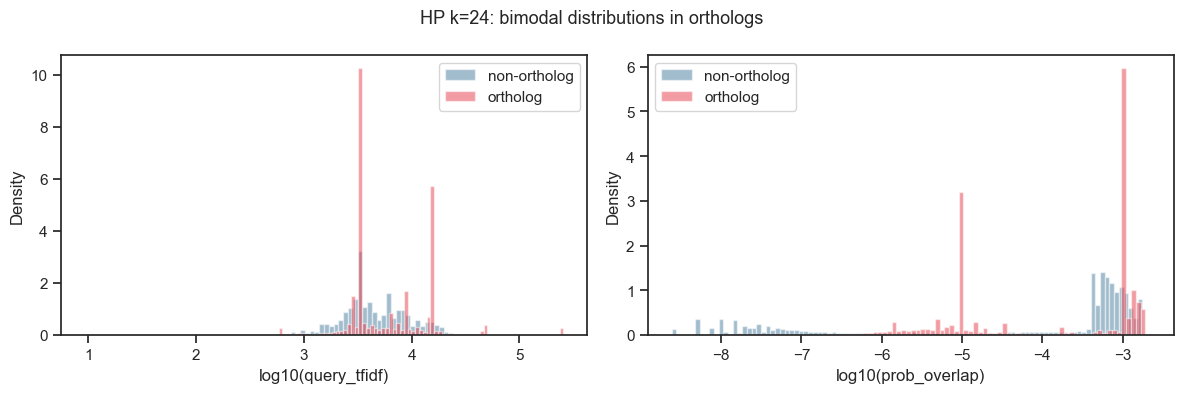

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(
    axes,
    ["log_query_tfidf", "log_prob_overlap"],
    ["log10(query_tfidf)", "log10(prob_overlap)"],
):
    ax.hist(
        non_orthologs[col].drop_nulls().to_numpy(),
        bins=100,
        alpha=0.5,
        color=NON_ORTHOLOG_COLOR,
        density=True,
        label="non-ortholog",
    )
    ax.hist(
        orthologs[col].drop_nulls().to_numpy(),
        bins=100,
        alpha=0.5,
        color=ORTHOLOG_COLOR,
        density=True,
        label="ortholog",
    )
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.legend()

fig.suptitle(f"HP k={KSIZE}: bimodal distributions in orthologs", fontsize=13)
fig.tight_layout()
plt.show()

## 3. Fit Gaussian Mixture Model to ortholog `query_tfidf`

Use a 2-component GMM to formally identify the two peaks and assign each ortholog to a peak.

In [14]:
X_orth = orthologs["log_query_tfidf"].drop_nulls().to_numpy().reshape(-1, 1)

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_orth)

means = gmm.means_.flatten()
order = np.argsort(means)
means_sorted = means[order]
stds_sorted = np.sqrt(gmm.covariances_.flatten())[order]
weights_sorted = gmm.weights_[order]

print("GMM fits (sorted by mean):")
for i, (m, s, w) in enumerate(zip(means_sorted, stds_sorted, weights_sorted)):
    print(f"  Component {i}: mean={m:.3f}, std={s:.3f}, weight={w:.3f}")

labels = gmm.predict(X_orth)
if means[0] > means[1]:
    labels = 1 - labels

# Align with rows that had non-null log_query_tfidf
null_mask = orthologs["log_query_tfidf"].is_null()
full_labels = np.full(len(orthologs), -1, dtype=np.int8)
full_labels[~null_mask.to_numpy()] = labels

# Build string labels directly to avoid Polars type-mismatch in .replace()
label_map = {0: "low", 1: "high", -1: None}
peak_str = [label_map[int(v)] for v in full_labels]

orthologs = orthologs.with_columns(pl.Series("gmm_peak", peak_str))

print(orthologs["gmm_peak"].value_counts())

GMM fits (sorted by mean):
  Component 0: mean=3.509, std=0.001, weight=0.352
  Component 1: mean=3.913, std=0.423, weight=0.648
shape: (2, 2)
┌──────────┬────────┐
│ gmm_peak ┆ count  │
│ ---      ┆ ---    │
│ str      ┆ u32    │
╞══════════╪════════╡
│ low      ┆ 245036 │
│ high     ┆ 448714 │
└──────────┴────────┘


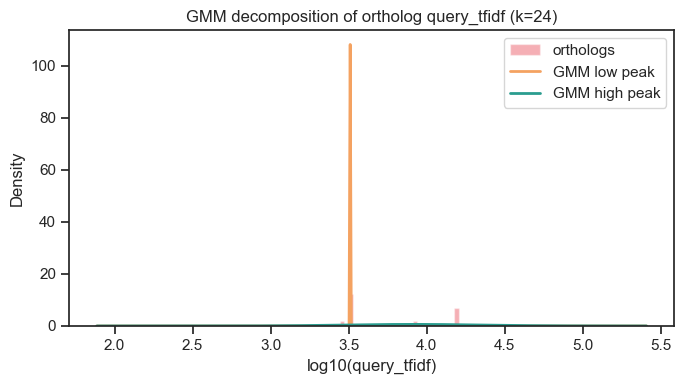

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    X_orth, bins=120, density=True, color=ORTHOLOG_COLOR, alpha=0.4, label="orthologs"
)

x_grid = np.linspace(X_orth.min(), X_orth.max(), 500)
for i, (m, s, w, c) in enumerate(
    zip(means_sorted, stds_sorted, weights_sorted, [LOW_PEAK_COLOR, HIGH_PEAK_COLOR])
):
    component = (
        w * (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - m) / s) ** 2)
    )
    ax.plot(x_grid, component, color=c, lw=2, label=f'GMM {["low","high"][i]} peak')

ax.set_xlabel("log10(query_tfidf)")
ax.set_ylabel("Density")
ax.set_title(f"GMM decomposition of ortholog query_tfidf (k={KSIZE})")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Candidate drivers of bimodality

Test each candidate feature: protein length, k-mer frequency, HP composition, and enrichment.

In [16]:
candidate_cols = [
    c
    for c in [
        "query_len",
        "target_len",
        "n_intersecting_hashes",
        "expected_shared_kmers",
        "mean_matched_kmer_freq",
        "sum_matched_kmer_freq",
        "enrichment",
        "containment",
    ]
    if c in orthologs.columns
]
print("Available candidate columns:", candidate_cols)

Available candidate columns: ['query_len', 'target_len', 'n_intersecting_hashes', 'expected_shared_kmers', 'mean_matched_kmer_freq', 'sum_matched_kmer_freq', 'enrichment', 'containment']


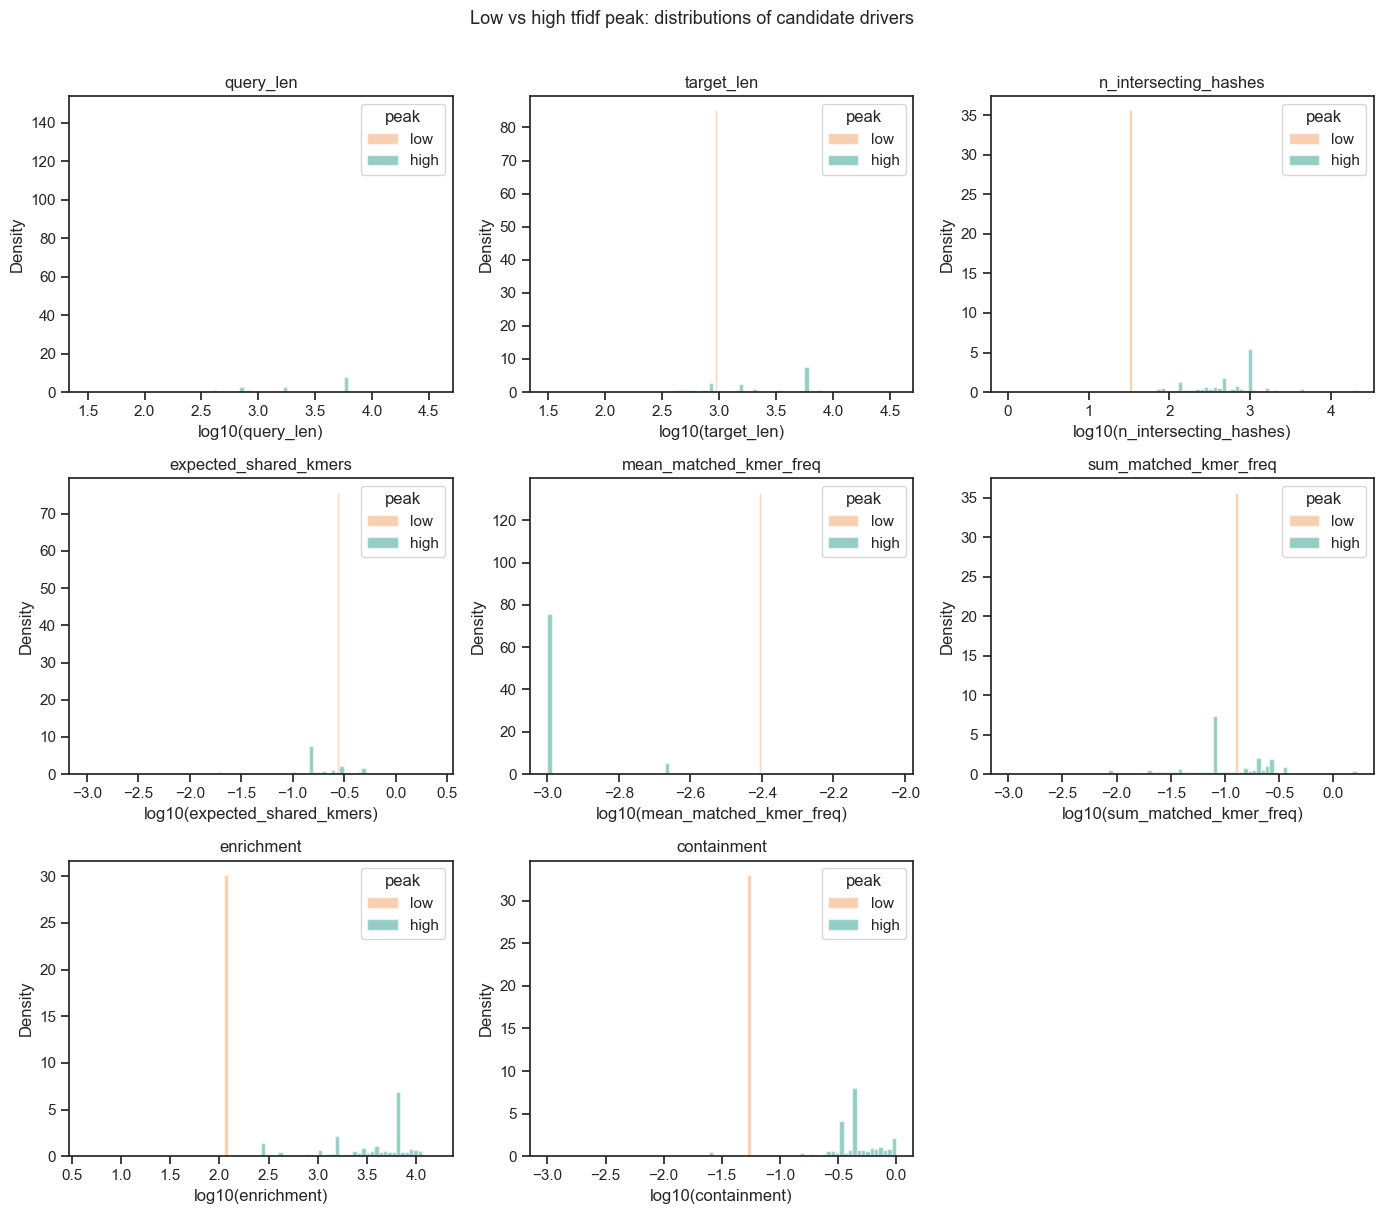

In [17]:
n_cols = len(candidate_cols)
ncols_plot = 3
nrows_plot = int(np.ceil(n_cols / ncols_plot))

fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(14, 4 * nrows_plot))
axes = axes.flatten()

for ax, col in zip(axes, candidate_cols):
    for peak, color in [("low", LOW_PEAK_COLOR), ("high", HIGH_PEAK_COLOR)]:
        vals = orthologs.filter(pl.col("gmm_peak") == peak)[col].drop_nulls().to_numpy()
        ax.hist(
            np.log10(vals.clip(1e-3)),
            bins=80,
            density=True,
            alpha=0.5,
            color=color,
            label=peak,
        )
    ax.set_xlabel(f"log10({col})")
    ax.set_ylabel("Density")
    ax.set_title(col)
    ax.legend(title="peak")

for ax in axes[n_cols:]:
    ax.set_visible(False)

fig.suptitle(
    "Low vs high tfidf peak: distributions of candidate drivers", fontsize=13, y=1.01
)
fig.tight_layout()
plt.show()

## 5. Protein-length stratification

Does protein length alone explain the two peaks?

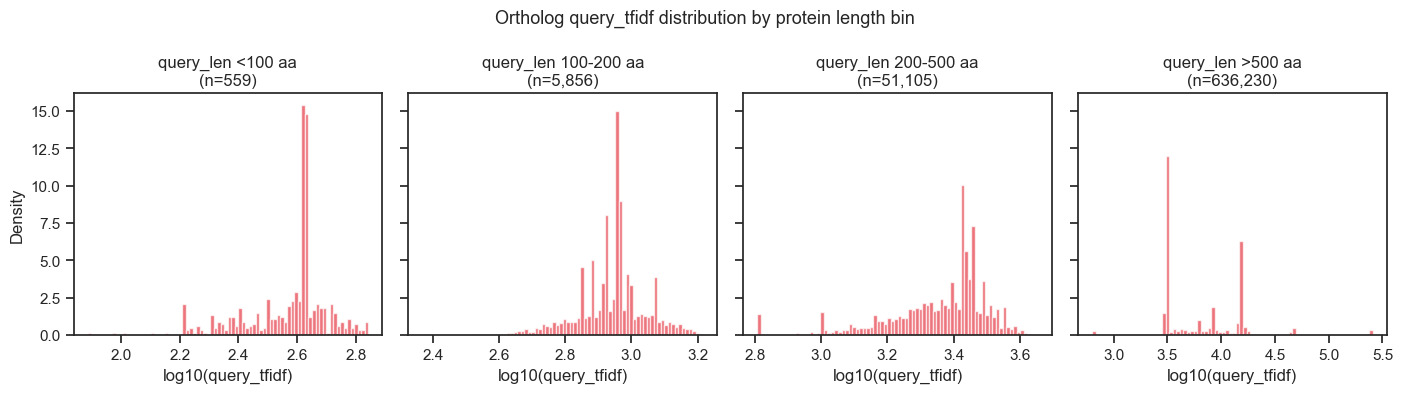

In [19]:
length_bins = [0, 100, 200, 500, float("inf")]
length_labels = ["<100", "100-200", "200-500", ">500"]

orthologs = orthologs.with_columns(
    pl.col("query_len")
    .cast(pl.Float64)
    .cut(breaks=[100, 200, 500], labels=length_labels)
    .alias("length_bin")
)

fig, axes = plt.subplots(1, len(length_labels), figsize=(14, 4), sharey=True)

for ax, lb in zip(axes, length_labels):
    vals = (
        orthologs.filter(pl.col("length_bin") == lb)["log_query_tfidf"]
        .drop_nulls()
        .to_numpy()
    )
    ax.hist(vals, bins=80, density=True, color=ORTHOLOG_COLOR, alpha=0.7)
    ax.set_title(f"query_len {lb} aa\n(n={len(vals):,})")
    ax.set_xlabel("log10(query_tfidf)")

axes[0].set_ylabel("Density")
fig.suptitle("Ortholog query_tfidf distribution by protein length bin", fontsize=13)
fig.tight_layout()
plt.show()

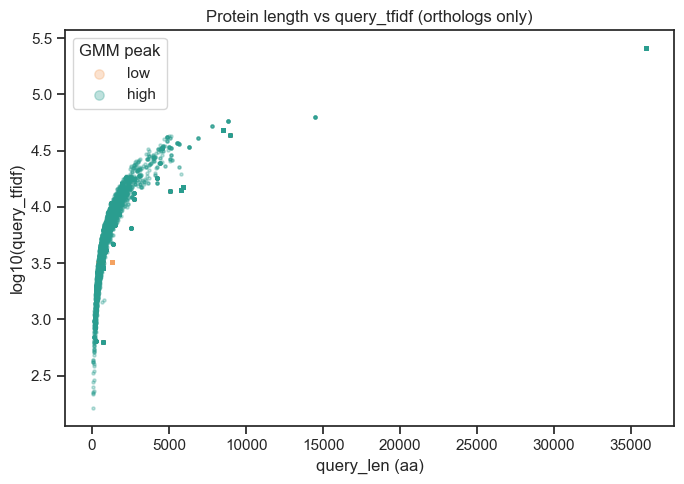

In [20]:
sample = orthologs.filter(pl.col("gmm_peak").is_not_null()).sample(
    n=min(20_000, len(orthologs)), seed=42
)

fig, ax = plt.subplots(figsize=(7, 5))
for peak, color in [("low", LOW_PEAK_COLOR), ("high", HIGH_PEAK_COLOR)]:
    sub = sample.filter(pl.col("gmm_peak") == peak)
    ax.scatter(
        sub["query_len"].to_numpy(),
        sub["log_query_tfidf"].to_numpy(),
        alpha=0.3,
        s=5,
        color=color,
        label=peak,
        rasterized=True,
    )

ax.set_xlabel("query_len (aa)")
ax.set_ylabel("log10(query_tfidf)")
ax.set_title("Protein length vs query_tfidf (orthologs only)")
ax.legend(title="GMM peak", markerscale=3)
fig.tight_layout()
plt.show()

## 6. HP composition (H-fraction) in matched k-mers

Do the two peaks differ in the hydrophobic fraction of matched regions?

In [21]:
if "h_fraction" in orthologs.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    for peak, color in [("low", LOW_PEAK_COLOR), ("high", HIGH_PEAK_COLOR)]:
        vals = (
            orthologs.filter(pl.col("gmm_peak") == peak)["h_fraction"]
            .drop_nulls()
            .to_numpy()
        )
        ax.hist(vals, bins=80, density=True, alpha=0.55, color=color, label=peak)
    ax.set_xlabel("H-fraction (hydrophobic residue fraction)")
    ax.set_ylabel("Density")
    ax.set_title("HP composition by GMM peak")
    ax.legend(title="peak")
    fig.tight_layout()
    plt.show()
else:
    print("h_fraction column not present — skipping HP composition plot")

h_fraction column not present — skipping HP composition plot


## 7. Statistical enrichment vs expected k-mers

The low peak may represent ortholog pairs where the observed k-mer overlap is not statistically elevated above the Poisson expectation.

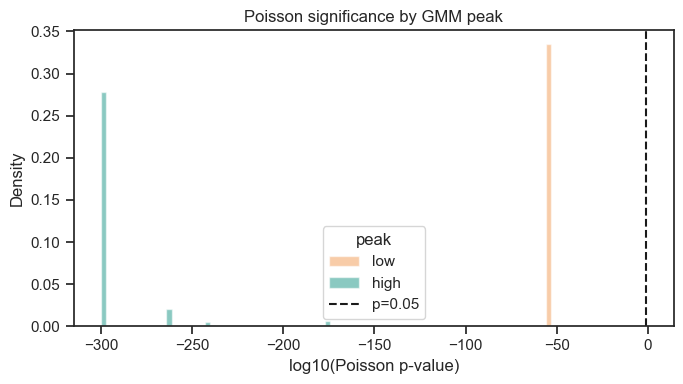

In [22]:
if {"n_intersecting_hashes", "expected_shared_kmers"}.issubset(orthologs.columns):
    k_orth = orthologs["n_intersecting_hashes"].cast(pl.Float64).to_numpy()
    lam_orth = orthologs["expected_shared_kmers"].cast(pl.Float64).to_numpy()
    poisson_p = _poisson.sf(k_orth - 1, lam_orth.clip(1e-10))

    orthologs = orthologs.with_columns(
        pl.Series("log_poisson_p", np.log10(poisson_p.clip(1e-300)))
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    for peak, color in [("low", LOW_PEAK_COLOR), ("high", HIGH_PEAK_COLOR)]:
        vals = (
            orthologs.filter(pl.col("gmm_peak") == peak)["log_poisson_p"]
            .drop_nulls()
            .to_numpy()
        )
        ax.hist(vals, bins=100, density=True, alpha=0.55, color=color, label=peak)
    ax.axvline(np.log10(0.05), color="k", ls="--", label="p=0.05")
    ax.set_xlabel("log10(Poisson p-value)")
    ax.set_ylabel("Density")
    ax.set_title("Poisson significance by GMM peak")
    ax.legend(title="peak")
    fig.tight_layout()
    plt.show()
else:
    print("Columns for Poisson test not available")

### Note on multiple testing for the Poisson p-values above

The Poisson p-values plotted above are used **descriptively** (characterizing the two GMM peaks),
not to call any new pair significant. But if they were used as a significance threshold, the
denominator would matter:

- The TSV contains ~18.8M pairs that share **≥1 k-mer** — zero-overlap pairs are absent (p=1.0 by definition).
- The true all-vs-all human × mouse search space is ~N_HUMAN_PROTEINS × N_MOUSE_PROTEINS ≈ 435M+.
- Using 18.8M instead of 435M as the Bonferroni denominator is ~23× less stringent.

See notebook 120 (`120_kmerseek_only_orthologs_conservative_threshold.ipynb`) for analysis using
the conservative Bonferroni threshold.

## 8. Summary table: low vs high peak characterisation

In [23]:
summary_cols = [
    c
    for c in [
        "query_len",
        "target_len",
        "n_intersecting_hashes",
        "expected_shared_kmers",
        "mean_matched_kmer_freq",
        "enrichment",
        "containment",
        "query_tfidf",
        "prob_overlap",
    ]
    if c in orthologs.columns
]

summary = (
    orthologs.filter(pl.col("gmm_peak").is_not_null())
    .group_by("gmm_peak")
    .agg([pl.col(c).median().alias(c) for c in summary_cols])
    .sort("gmm_peak")
    .to_pandas()
    .set_index("gmm_peak")
    .T.rename(columns={"low": "low-peak median", "high": "high-peak median"})
)
summary["ratio (high/low)"] = summary["high-peak median"] / summary["low-peak median"]
summary.style.format("{:.3g}").background_gradient(
    subset=["ratio (high/low)"], cmap="RdYlGn"
)

gmm_peak,high-peak median,low-peak median,ratio (high/low)
query_len,1.72e+03,1.3e+03,1.32
target_len,1.58e+03,945,1.67
n_intersecting_hashes,589,32,18.4
expected_shared_kmers,0.157,0.271,0.58
mean_matched_kmer_freq,9.28e-05,0.00397,0.0234
enrichment,4.43e+03,118,37.6
containment,0.432,0.0541,7.99
query_tfidf,8.66e+03,3.23e+03,2.68
prob_overlap,9.62e-06,0.00111,0.00869


## 9. BIC model selection: how many peaks?

Formally test whether 1, 2, or 3 Gaussian components best describe the ortholog `query_tfidf` distribution.

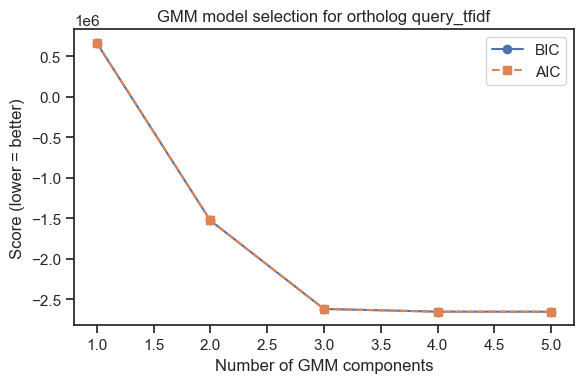

Best n_components by BIC: 5


In [24]:
bics = []
aics = []
n_components_range = range(1, 6)

for n in n_components_range:
    g = GaussianMixture(n_components=n, random_state=42)
    g.fit(X_orth)
    bics.append(g.bic(X_orth))
    aics.append(g.aic(X_orth))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_components_range, bics, "o-", label="BIC")
ax.plot(n_components_range, aics, "s--", label="AIC")
ax.set_xlabel("Number of GMM components")
ax.set_ylabel("Score (lower = better)")
ax.set_title("GMM model selection for ortholog query_tfidf")
ax.legend()
fig.tight_layout()
plt.show()

best_n_bic = n_components_range[np.argmin(bics)]
print(f"Best n_components by BIC: {best_n_bic}")